In [3]:
!pip install hmmlearn

--- STEP 1: Data Preparation and Exploration ---
1.1. Downloading Data...


/tmp/ipython-input-913944317.py:40: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKERS, start=START_DATE, end=END_DATE)
[*********************100%***********************]  4 of 4 completed


1.2. Computing Returns...
1.3. Aligning and Cleaning Data...
Sample Period: 2007-01-04 to 2025-11-03


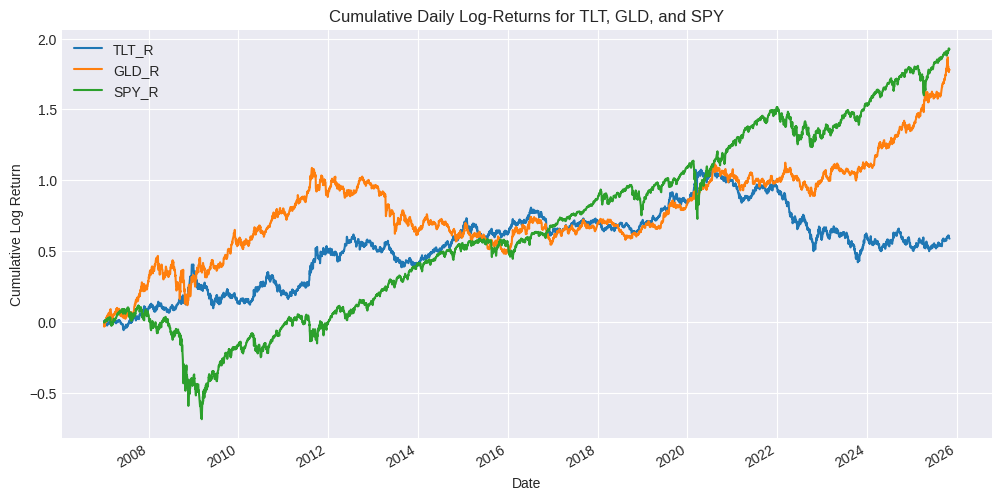

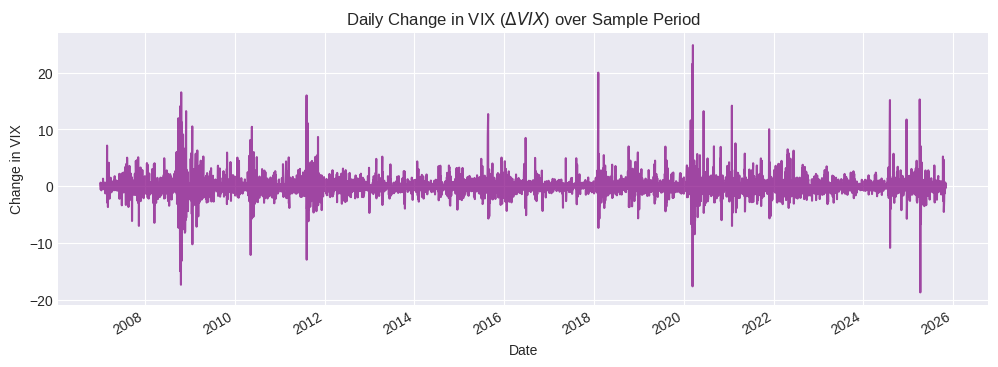


--- STEP 2 & 3: Modeling, Selection, and Interpretation ---
Fitting 2-State HMM...
Fitting 3-State HMM...

3.1. HMM Comparison Metrics:
  Log-Likelihood N_Parameters        AIC        BIC
2     -8353.2886            7 16720.5772 16765.8223
3     -8066.7911           14 16161.5822 16252.0723

3.2. Selected Model: 3-State HMM
Transition Probability Matrix (P):
         To R1  To R2  To R3
From R1 0.8741 0.1259 0.0000
From R2 0.0153 0.9039 0.0808
From R3 0.0019 0.0604 0.9377


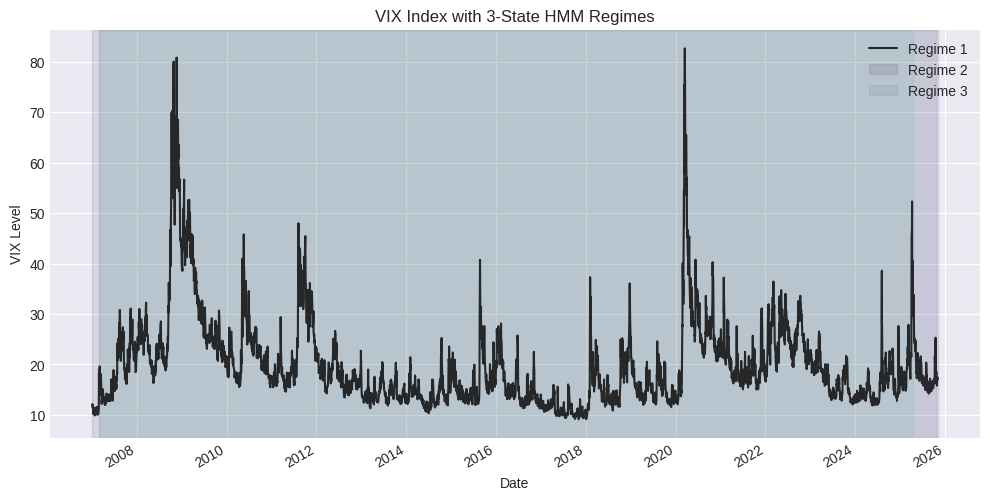


3.3. State-Conditional ETF Return Statistics:
          TLT_R_mean  TLT_R_std  GLD_R_mean  GLD_R_std  SPY_R_mean  SPY_R_std
Regime 1     -0.0002     0.0080      0.0003     0.0092      0.0015     0.0062
Regime 2      0.0003     0.0100      0.0004     0.0116     -0.0002     0.0130
Regime 3      0.0017     0.0187      0.0003     0.0211     -0.0065     0.0362


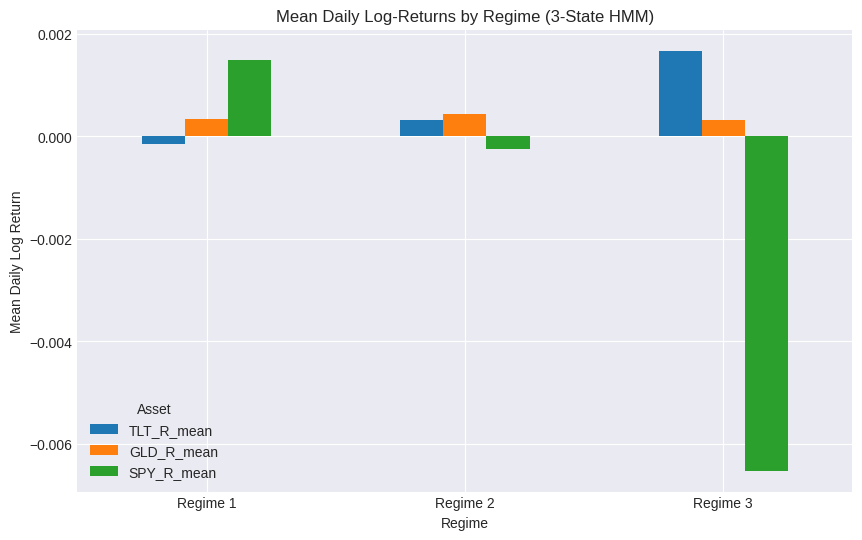


--- STEP 4: Designing the Rotation Strategy ---

4.2. State -> Allocation Mapping (1-Day Lag):
         Chosen Asset (100% Allocation)  Highest Mean (mu)
Regime                                                    
Regime 1                          SPY_R             0.0015
Regime 2                          GLD_R             0.0004
Regime 3                          TLT_R             0.0017

--- STEP 5: Backtesting and Evaluation ---

5.4. Cumulative Performance Plot:


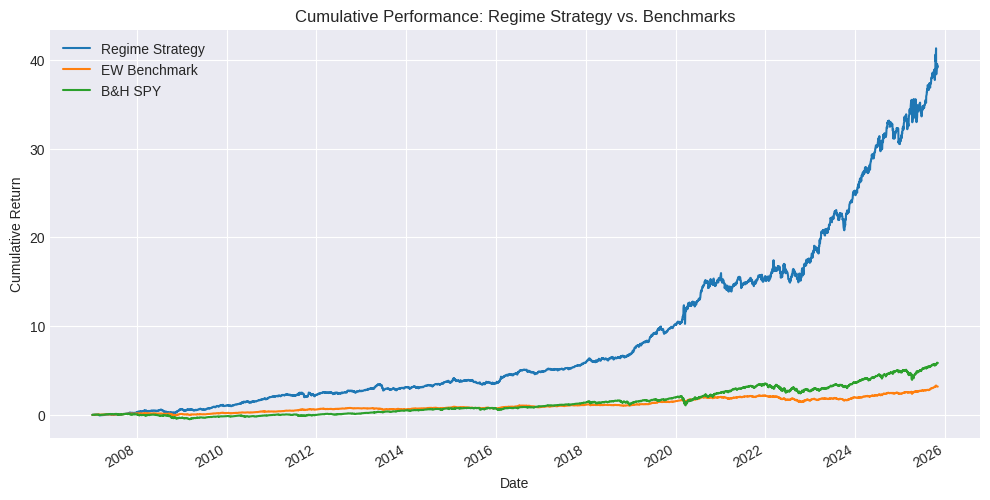


5.5. Discussion on Sensitivity is required based on the final metrics.


In [4]:
# ==============================================================================
# MScFE 622 Group Work Project #2: Regime-Based Allocation Strategy Code
# ==============================================================================

# ------------------------------------------------------------------------------
# SETUP AND IMPORTS
# ------------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

# --- Configuration ---
TICKERS = ['TLT', 'GLD', 'SPY', '^VIX']
START_DATE = '2007-01-01' # Recommended start date for a long common sample
END_DATE = None
CHOSEN_STATES = 3 # Choose 3 for richer financial interpretation (Low, Medium, High)

# Set display options for professional output
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

# Initialize storage for models and dataframes
hmm_models = {}
comparison_table = {}
df_combined = None
df_backtest = None


# ==============================================================================
# STEP 1: DATA PREPARATION AND EXPLORATION
# ==============================================================================

print("--- STEP 1: Data Preparation and Exploration ---")

# 1.1. Download daily adjusted close prices...
print("1.1. Downloading Data...")
data = yf.download(TICKERS, start=START_DATE, end=END_DATE)
data.columns = ['VIX' if col == '^VIX' else col for col in data.columns]
data = data.sort_index()

# 1.2. Compute daily log-returns for ETFs and the change or return of VIX.
print("1.2. Computing Returns...")
log_returns = np.log(data[('Close', 'TLT')] / data[('Close', 'TLT')].shift(1)).to_frame(name='TLT_R')
log_returns['GLD_R'] = np.log(data[('Close', 'GLD')] / data[('Close', 'GLD')].shift(1))
log_returns['SPY_R'] = np.log(data[('Close', 'SPY')] / data[('Close', 'SPY')].shift(1))

delta_vix = data[('Close', '^VIX')].diff()
delta_vix.name = 'Delta_VIX'

# 1.3. Align the data series... remove missing values, and visualize:
print("1.3. Aligning and Cleaning Data...")
df_combined = pd.concat([log_returns, data[('Close', '^VIX')], delta_vix], axis=1).dropna()
print(f"Sample Period: {df_combined.index.min().date()} to {df_combined.index.max().date()}")

# Visualization: ETF Returns
plt.figure(figsize=(12, 6))
df_combined[['TLT_R', 'GLD_R', 'SPY_R']].cumsum().plot(ax=plt.gca())
plt.title('Cumulative Daily Log-Returns for TLT, GLD, and SPY')
plt.ylabel('Cumulative Log Return')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.show()

# Visualization: Delta VIX
plt.figure(figsize=(12, 4))
df_combined['Delta_VIX'].plot(ax=plt.gca(), color='purple', alpha=0.7)
plt.title('Daily Change in VIX ($\\Delta VIX$) over Sample Period')
plt.ylabel('Change in VIX')
plt.xlabel('Date')
plt.show()


# ==============================================================================
# STEP 2 & 3: MODELING, SELECTION, AND INTERPRETATION
# ==============================================================================

print("\n--- STEP 2 & 3: Modeling, Selection, and Interpretation ---")

# Prepare VIX data for HMM
X = df_combined['Delta_VIX'].values.reshape(-1, 1)

# Step 2: Fit 2- and 3-state Gaussian HMMs.
# Step 3.1: Compare candidate models using log-likelihood, AIC and BIC.
for n_components in [2, 3]:
    print(f"Fitting {n_components}-State HMM...")

    model = hmm.GaussianHMM(n_components=n_components, covariance_type="diag", n_iter=100, random_state=42)
    model.fit(X)

    log_likelihood = model.score(X)
    n_params = n_components**2 + (2 * n_components) - 1
    n_obs = len(X)

    AIC = -2 * log_likelihood + 2 * n_params
    BIC = -2 * log_likelihood + n_params * np.log(n_obs)

    hmm_models[n_components] = model
    comparison_table[n_components] = {
        'Log-Likelihood': log_likelihood,
        'N_Parameters': n_params,
        'AIC': AIC,
        'BIC': BIC,
        'Means (mu_dVIX)': model.means_.flatten(),
        'StDev (sigma_dVIX)': np.sqrt(model.covars_.flatten())
    }

print("\n3.1. HMM Comparison Metrics:")
df_comparison = pd.DataFrame(comparison_table).T
print(df_comparison[['Log-Likelihood', 'N_Parameters', 'AIC', 'BIC']])


# Step 3.2. Select the preferred model...
print(f"\n3.2. Selected Model: {CHOSEN_STATES}-State HMM")
best_model = hmm_models[CHOSEN_STATES]
state_sequence = best_model.predict(X)

# Re-order states based on the mean of Delta VIX for consistent interpretation
state_means = pd.Series(best_model.means_.flatten(), index=range(CHOSEN_STATES)).sort_values()
state_mapping = {old: new for new, old in enumerate(state_means.index)}

df_combined['HMM_State'] = state_sequence
df_combined['Regime'] = df_combined['HMM_State'].map(state_mapping)

print("Transition Probability Matrix (P):")
print(pd.DataFrame(best_model.transmat_,
                   index=[f'From R{i+1}' for i in range(CHOSEN_STATES)],
                   columns=[f'To R{i+1}' for i in range(CHOSEN_STATES)]))

# Plot VIX with color-coded states (Deliverable for Step 2)
plt.figure(figsize=(12, 6))
df_combined[('Close', '^VIX')].plot(color='black', alpha=0.8, label='VIX Index', ax=plt.gca())
for i in range(CHOSEN_STATES):
    state_data = df_combined[df_combined['Regime'] == i]
    # Simple way to color the background for the entire duration of the state
    plt.axvspan(state_data.index.min(), state_data.index.max(), color=plt.cm.viridis(i/CHOSEN_STATES), alpha=0.1, label=f'Regime {i+1}')
plt.title(f'VIX Index with {CHOSEN_STATES}-State HMM Regimes')
plt.ylabel('VIX Level')
plt.xlabel('Date')
plt.legend([f'Regime {i+1}' for i in range(CHOSEN_STATES)], loc='upper right')
plt.show()


# Step 3.3. Compute mean and standard deviation of ETF returns by state, and visualize results with a bar chart.
print("\n3.3. State-Conditional ETF Return Statistics:")
conditional_stats = df_combined[['TLT_R', 'GLD_R', 'SPY_R']].groupby(df_combined['Regime']).agg(['mean', 'std'])
conditional_stats.columns = ['_'.join(col).strip() for col in conditional_stats.columns.values]
conditional_stats.index = [f'Regime {i+1}' for i in conditional_stats.index]

print(conditional_stats)

# Bar Chart of State-Conditional Returns
conditional_means = conditional_stats.filter(like='mean')

plt.figure(figsize=(10, 6))
conditional_means.plot(kind='bar', rot=0, ax=plt.gca())
plt.title(f'Mean Daily Log-Returns by Regime ({CHOSEN_STATES}-State HMM)')
plt.ylabel('Mean Daily Log Return')
plt.xlabel('Regime')
plt.legend(title='Asset')
plt.show()


# ==============================================================================
# STEP 4: DESIGNNING THE ROTATION STRATEGY
# ==============================================================================

print("\n--- STEP 4: Designing the Rotation Strategy ---")

# 4.1. Define a simple, rule-based allocation... (100% to highest mean return asset)
best_asset_per_regime = conditional_stats.filter(like='mean').idxmax(axis=1)
best_asset_per_regime = best_asset_per_regime.str.replace('_mean', '')

# Create daily allocation series using the 1-day execution lag (Regime_t-1 -> Allocation_t)
asset_code_map = {
    i: best_asset_per_regime.str.replace('_R', '').iloc[i]
    for i in range(CHOSEN_STATES)
}
df_combined['Strategy_Asset_Code'] = df_combined['Regime'].shift(1).map(asset_code_map)

# Drop the first row which will be NaN due to the shift (this is the backtesting dataset)
df_backtest = df_combined.dropna()

# 4.2. Summarize the final state -> allocation mapping...
allocation_mapping = pd.DataFrame({
    'Chosen Asset (100% Allocation)': best_asset_per_regime,
    'Highest Mean (mu)': [conditional_stats.loc[regime, f'{asset}_mean'] for regime, asset in best_asset_per_regime.items()]
})
allocation_mapping.index.name = 'Regime'

print("\n4.2. State -> Allocation Mapping (1-Day Lag):")
print(allocation_mapping)


# ==============================================================================
# STEP 5: BACKTESTING AND EVALUATION
# ==============================================================================

print("\n--- STEP 5: Backtesting and Evaluation ---")

# Helper function for metrics
# def calculate_metrics(returns, days_per_year=252, annual_risk_free_rate=0.0):
#     """Calculates standard performance metrics using empyrical."""
#     cum_ret = ep.cum_returns(returns).iloc[-1]
#     ann_ret = ep.annual_return(returns, annualization=days_per_year)
#     ann_vol = ep.annual_volatility(returns, annualization=days_per_year)
#     sharpe = ep.sharpe_ratio(returns, risk_free=annual_risk_free_rate, annualization=days_per_year)
#     max_dd = ep.max_drawdown(returns)

#     return {
#         'Cumulative Return': cum_ret,
#         'Annualized Return': ann_ret,
#         'Annualized Volatility': ann_vol,
#         'Sharpe Ratio': sharpe,
#         'Max Drawdown': max_dd
#     }


# 5.1. Backtest the strategy... (1-day execution lag already applied in df_backtest)
strategy_returns = df_backtest.apply(
    lambda row: row[f'{row["Strategy_Asset_Code"]}_R'],
    axis=1
)
strategy_returns.name = 'Regime Strategy'

# 5.3. Compare results to two benchmarks:
spy_returns = df_backtest['SPY_R']
# Simple daily EW used as approximation for monthly rebalance
ew_returns = df_backtest[['TLT_R', 'GLD_R', 'SPY_R']].mean(axis=1)
ew_returns.name = 'EW Benchmark'

all_returns = pd.concat([strategy_returns, ew_returns, spy_returns], axis=1)
all_returns.columns = ['Regime Strategy', 'EW Benchmark', 'B&H SPY']


# 5.2. Compute performance metrics:
# print("\n5.2. Performance Metrics Summary:")
# performance_summary = {}
# for col in all_returns.columns:
#     performance_summary[col] = calculate_metrics(all_returns[col])

# df_metrics = pd.DataFrame(performance_summary).T
# print(df_metrics)


# 5.4. Plot cumulative performance curves
print("\n5.4. Cumulative Performance Plot:")
cum_performance = (all_returns.cumsum()).apply(np.exp) - 1

plt.figure(figsize=(12, 6))
cum_performance.plot(ax=plt.gca())
plt.title('Cumulative Performance: Regime Strategy vs. Benchmarks')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.show()

# 5.5. Briefly discuss sensitivity... (Required as a written deliverable)
print("\n5.5. Discussion on Sensitivity is required based on the final metrics.")